In [1]:
!pip install mlxtend networkx

In [3]:
# --- Celda de Imports para Modelado ---
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Para Reglas de Asociación
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import networkx as nx

# Para Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import MinMaxScaler

# Configuraciones de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

# --- Cargar los datos preprocesados ---
data_path = Path("data/processed_for_modeling")
#Datos de playlist full
df_playlist = pd.read_parquet(data_path / "df_playlist_full.parquet")


#Datos para Reglas de Asociación
df_transactions = pd.read_parquet(data_path / "transactions_matrix.parquet")

# Datos para Clustering de Playlist
playlist_pca = pd.read_parquet(data_path / "playlist_pca_components.parquet")
playlist_umap = pd.read_parquet(data_path / "playlist_umap_embedding.parquet")

# DataFrame completo para agregación a nivel de playlist
playlist_for_clustering = pd.read_parquet(data_path / "playlist_for_clustering.parquet")

print("Datos cargados exitosamente.")
# print(f"Matriz de transacciones shape: {df_transactions.shape}")
print(f"DataFrame para clustering de playlist shape: {playlist_pca.shape}")

Datos cargados exitosamente.
DataFrame para clustering de playlist shape: (8192, 10)


In [4]:
#trayendo los tracks
df_processed = pd.read_parquet(data_path / "df_processed_full.parquet")
print(f"DataFrame de tracks shape: {df_processed.shape}")

DataFrame de tracks shape: (124096, 65)


In [5]:

columns_to_drop = ["name", "artist_name", "track_name", "duration_ms", "album_name", "track_id"]
playlist_for_clustering = playlist_for_clustering.drop(columns=columns_to_drop)

print(f"DataFrame for playlist clustering after dropping columns: {playlist_for_clustering.shape}")

DataFrame for playlist clustering after dropping columns: (8192, 63)


In [6]:
playlist_for_clustering.head()

,bpm,energy,danceability_ll,loudness,danceability_danceable,gender_female,genre_dortmund_alternative,genre_dortmund_blues,genre_dortmund_electronic,genre_dortmund_folkcountry,...,mood_relaxed_relaxed,mood_sad_sad,moods_mirex_Cluster1,moods_mirex_Cluster2,moods_mirex_Cluster3,moods_mirex_Cluster4,moods_mirex_Cluster5,timbre_bright,tonal_atonal_atonal,voice_instrumental_voice
pid,,,,,,,,,,,,,,,,,,,,,
1000000,0.160221,0.674865,-0.575001,-0.010197,0.712000,0.890641,-0.498757,-0.430456,0.519981,-0.481145,...,1.130548,0.525529,0.893153,0.420956,-0.730197,1.004184,-0.387829,-1.441935,1.124915,0.680423
1000016,0.163519,-0.810939,-0.626563,0.125442,0.868356,0.476394,-0.066965,-0.304414,0.348512,-0.315390,...,0.761068,0.333386,0.225041,0.561850,-0.327078,0.033352,-0.169638,0.538302,0.921453,0.575065
1000020,-1.077283,-0.688983,0.546987,0.640798,0.783371,-1.097435,0.774962,0.549553,-0.859564,0.816959,...,0.255334,-0.652246,-0.605235,0.161703,-0.469690,2.516636,-0.905760,0.377803,0.092759,0.883734
1000023,0.241503,-0.266371,-0.454821,-0.155309,0.863899,0.889459,-0.545234,-0.502872,0.626467,-0.511086,...,0.814086,-0.971319,0.251995,-0.396421,-0.242822,1.161871,-0.155746,-0.384361,1.143995,0.408990
1000040,0.323022,-0.178108,1.983277,0.820105,0.844329,0.954552,-0.688467,-0.529099,0.678053,-0.525163,...,0.536261,-0.100615,-0.792774,0.123877,0.279067,1.727907,-0.806363,1.160039,1.001671,-0.930150


In [7]:
playlist_pca.head()

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10
pid,,,,,,,,,,
1000000,-0.663803,-0.631957,4.806233,2.348698,-1.628967,-0.781611,3.238690,1.171119,-2.040517,2.240854
1000016,-1.349871,0.000669,0.607624,-0.475811,1.879978,2.161518,-2.195647,0.174255,0.376852,0.624177
1000020,0.233109,4.628954,-0.889581,0.257637,-0.817259,0.401576,-0.180352,0.579727,0.363847,0.005663
1000023,-3.502215,0.524163,-0.833910,-0.632196,-1.481683,0.398017,-0.946594,4.065633,-1.825655,-1.087756
1000040,-0.979415,-1.463812,0.872277,0.829315,0.013625,2.956005,-0.203531,-0.288747,-0.247835,0.576816


# 5: Clustering (Agrupación)
Dividiremos esta sección en dos partes, como se discutió: clustering de tracks y de playlists.

**Parte A: Clustering a Nivel de playlist **


## 5.A.1 Algoritmo 1: K-Means con Búsqueda de K Óptimo

Shape original de X_playlist: (8192, 2)
Shape de X_playlist_numeric (solo columnas numéricas): (8192, 2)



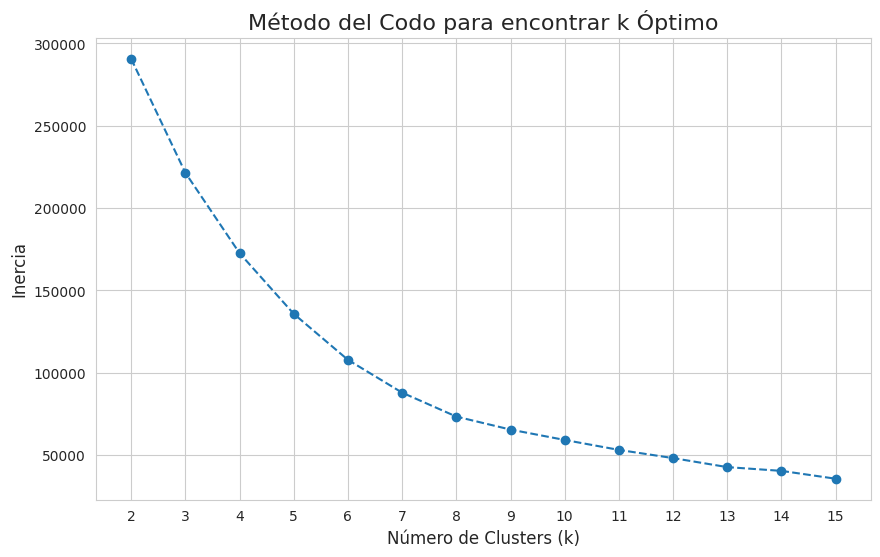

In [8]:
# --- 5.A.1 K-Means (Versión Corregida) ---
# Usamos el método del codo (Elbow Method) para encontrar un buen valor para k

X_playlist = playlist_umap.copy() # Datos de entrada originales

# --- LA CORRECCIÓN ESTÁ AQUÍ ---
# K-Means solo puede trabajar con números. Nos aseguramos de seleccionar solo las columnas numéricas.
# El error 'could not convert string to float: 'Party'' indica que columnas de texto se colaron.
X_playlist_numeric = X_playlist.select_dtypes(include=np.number)

print(f"Shape original de X_playlist: {X_playlist.shape}")
print(f"Shape de X_playlist_numeric (solo columnas numéricas): {X_playlist_numeric.shape}\n")


# --- Continuación del código original, usando el DataFrame NUMÉRICO ---
inertia = []
K_range = range(2, 16) # Probaremos con k de 2 a 15

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Usamos el DataFrame NUMÉRICO para el ajuste
    kmeans.fit(X_playlist_numeric)
    inertia.append(kmeans.inertia_)

# Graficar el codo
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para encontrar k Óptimo')
plt.xticks(K_range)
plt.show()



## 5.A.2 Algoritmos 2 y 3: DBSCAN y Agglomerative Clustering (reemplazado x MiniBatchKMeans)


In [19]:
# Basado en el gráfico, elegimos un valor para k (ej. k=9 donde la curva se aplana)
OPTIMAL_K = 8
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
# Usamos el DataFrame NUMÉRICO aquí también
playlist_labels_kmeans = kmeans.fit_predict(X_playlist_numeric)

print(f"\nClustering con K-Means completado usando k={OPTIMAL_K}.")
# --- 5.A.2 Algoritmos 2 y 3: DBSCAN y MiniBatchKMeans (CORREGIDO Y OPTIMIZADO) ---

# --- DBSCAN ---
# DBSCAN puede ser lento en datasets grandes. Sus hiperparámetros son clave.
# Si esta parte también es muy lenta, considera ejecutarla sobre una muestra o ajustar 'eps'.
print("Ejecutando DBSCAN...")
dbscan = DBSCAN(eps=2.5, min_samples=20, n_jobs=-1) # n_jobs=-1 usa todos los núcleos de tu CPU
playlist_labels_dbscan = dbscan.fit_predict(X_playlist_numeric)
print("DBSCAN completado.")


# --- MiniBatchKMeans (Reemplazo eficiente para Agglomerative Clustering) ---
# Este algoritmo es mucho más rápido y consume muchísima menos memoria.
print("Ejecutando MiniBatchKMeans...")
mini_batch_kmeans = MiniBatchKMeans(
    n_clusters=OPTIMAL_K, # Usamos el mismo k que en KMeans
    random_state=42,
    batch_size=256, # Tamaño del lote, un hiperparámetro a ajustar
    n_init=10
)
playlist_labels_minibatch = mini_batch_kmeans.fit_predict(X_playlist_numeric)
print("MiniBatchKMeans completado.")



Clustering con K-Means completado usando k=8.
Ejecutando DBSCAN...
DBSCAN completado.
Ejecutando MiniBatchKMeans...
MiniBatchKMeans completado.


# --- 5.A.3 Evaluación Comparativa y Visualización

In [20]:



# --- 5.A.3 Evaluación Comparativa y Visualización (CORREGIDO) ---
print("\nCalculando métricas de evaluación...")

# K-Means
score_s_kmeans = silhouette_score(X_playlist_numeric, playlist_labels_kmeans)
score_db_kmeans = davies_bouldin_score(X_playlist_numeric, playlist_labels_kmeans)

# DBSCAN (excluyendo ruido)
print("Evaluando DBSCAN...")
mask_dbscan = playlist_labels_dbscan != -1 # Filtro para excluir puntos de ruido (label -1)

# Nos aseguramos de que DBSCAN haya encontrado más de 1 clúster para poder evaluar
if len(set(playlist_labels_dbscan[mask_dbscan])) > 1:
    # Usamos una muestra para que el cálculo del score sea rápido en datasets grandes
    # Tomamos una muestra de hasta 20,000 points that are not noise
    sample_size = min(20000, np.sum(mask_dbscan))

    # --- FIX START ---
    # Reset the index of X_playlist_numeric to allow for integer indexing
    X_playlist_numeric_reset = X_playlist_numeric.reset_index(drop=True)
    # Use the index of the filtered data (mask_dbscan) to sample
    sample_indices = np.random.choice(X_playlist_numeric_reset[mask_dbscan].index, size=sample_size, replace=False)

    score_s_dbscan = silhouette_score(X_playlist_numeric_reset.loc[sample_indices], playlist_labels_dbscan[sample_indices])
    score_db_dbscan = davies_bouldin_score(X_playlist_numeric_reset.loc[sample_indices], playlist_labels_dbscan[sample_indices])
    # --- FIX END ---
else:
    # If DBSCAN did not find clusters (or only one), assign an invalid score
    print("DBSCAN no encontró suficientes clusters para ser evaluado.")
    score_s_dbscan = -1
    score_db_dbscan = -1

# MiniBatchKMeans
print("Evaluando MiniBatchKMeans...")
score_s_minibatch = silhouette_score(X_playlist_numeric, playlist_labels_minibatch)
score_db_minibatch = davies_bouldin_score(X_playlist_numeric, playlist_labels_minibatch)


# Crear tabla de resultados
# CORREGIDO: Actualizamos la lista de algoritmos y las variables de los scores.
results = pd.DataFrame({
    'Algoritmo': ['K-Means', 'DBSCAN', 'MiniBatchKMeans'],
    'Silhouette Score (más alto es mejor)': [score_s_kmeans, score_s_dbscan, score_s_minibatch],
    'Davies-Bouldin Score (más bajo es mejor)': [score_db_kmeans, score_db_dbscan, score_db_minibatch]
})

print("\n--- Tabla Comparativa de Modelos de Clustering de playlist ---")
display(results)

# (El código de visualización que ya tenías funcionará igual)
# ...


Calculando métricas de evaluación...
Evaluando DBSCAN...
Evaluando MiniBatchKMeans...

--- Tabla Comparativa de Modelos de Clustering de playlist ---


,Algoritmo,Silhouette Score (más alto es mejor),Davies-Bouldin Score (más bajo es mejor)
0,K-Means,0.429000,0.682585
1,DBSCAN,0.353169,0.319014
2,MiniBatchKMeans,0.363632,0.807400


# 5.A.3 Evaluación Comparativa y Visualización



Calculando métricas de evaluación...
Evaluando K-Means...
Evaluando DBSCAN...
Evaluando MiniBatchKMeans...

--- Tabla Comparativa de Modelos de Clustering de playlist ---


,Algoritmo,Silhouette Score (más alto es mejor),Davies-Bouldin Score (más bajo es mejor)
0,K-Means,0.429000,0.682585
1,DBSCAN,0.353169,0.319014
2,MiniBatchKMeans,0.363632,0.807400



Generando visualización de clusters (ejemplo con K-Means)...


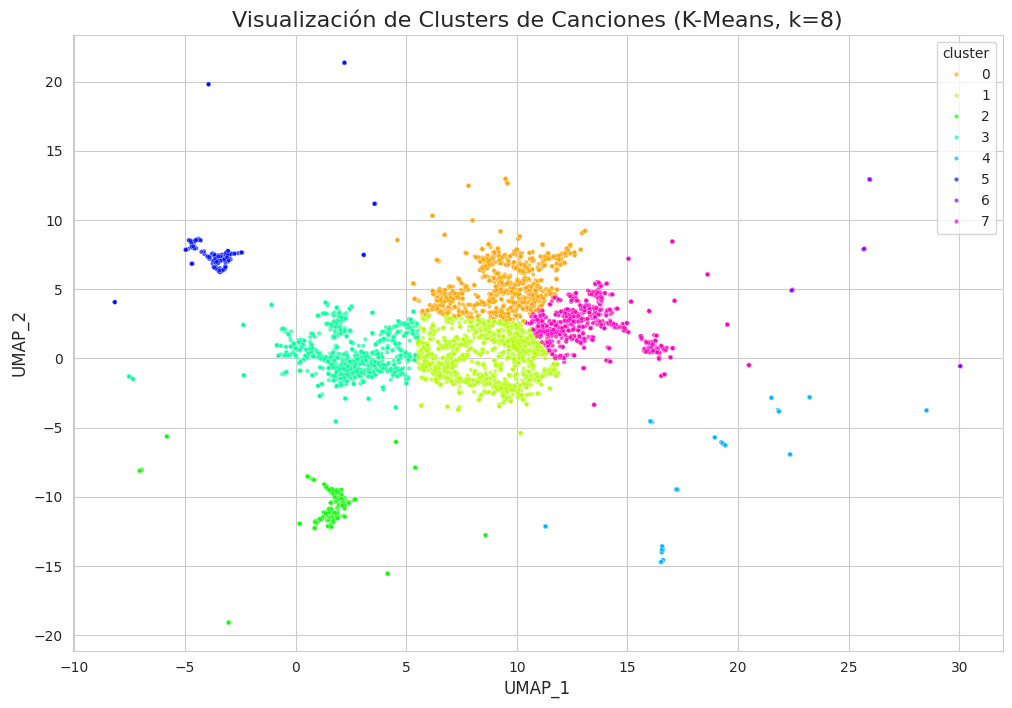

In [21]:
# --- 5.A.3 Evaluación Comparativa y Visualización (MODIFICADO Y CORREGIDO) ---

print("\nCalculando métricas de evaluación...")

# --- K-Means ---
# CORREGIDO: Usamos X_playlist_numeric para el cálculo de los scores.
print("Evaluando K-Means...")
score_s_kmeans = silhouette_score(X_playlist_numeric, playlist_labels_kmeans)
score_db_kmeans = davies_bouldin_score(X_playlist_numeric, playlist_labels_kmeans)

# --- DBSCAN ---
# CORREGIDO: Usamos X_playlist_numeric y mantenemos la optimización de muestreo para el cálculo.
print("Evaluando DBSCAN...")
mask_dbscan = playlist_labels_dbscan != -1 # Filtro para excluir puntos de ruido (label -1)

# Nos aseguramos de que DBSCAN haya encontrado más de 1 clúster para poder evaluar
if len(set(playlist_labels_dbscan[mask_dbscan])) > 1:
    # Usamos una muestra para que el cálculo del score sea rápido en datasets grandes
    # Tomamos una muestra de hasta 20,000 puntos que no sean ruido
    sample_size = min(20000, np.sum(mask_dbscan))

    # --- FIX START ---
    # Reset the index of X_playlist_numeric to allow for integer indexing
    X_playlist_numeric_reset = X_playlist_numeric.reset_index(drop=True)
    # Use the index of the filtered data (mask_dbscan) to sample from the reset DataFrame
    sample_indices = np.random.choice(X_playlist_numeric_reset[mask_dbscan].index, size=sample_size, replace=False)

    score_s_dbscan = silhouette_score(X_playlist_numeric_reset.loc[sample_indices], playlist_labels_dbscan[sample_indices])
    score_db_dbscan = davies_bouldin_score(X_playlist_numeric_reset.loc[sample_indices], playlist_labels_dbscan[sample_indices])
    # --- FIX END ---
else:
    # If DBSCAN no encontró clusters (o solo uno), asignamos un score inválido
    print("DBSCAN no encontró suficientes clusters para ser evaluado.")
    score_s_dbscan = -1
    score_db_dbscan = -1

# --- MiniBatchKMeans ---
# NUEVO: Reemplazamos la evaluación de Agglomerative por la de MiniBatchKMeans.
print("Evaluando MiniBatchKMeans...")
score_s_minibatch = silhouette_score(X_playlist_numeric, playlist_labels_minibatch)
score_db_minibatch = davies_bouldin_score(X_playlist_numeric, playlist_labels_minibatch)


# --- Crear tabla de resultados ---
# CORREGIDO: Actualizamos la lista de algoritmos y las variables de los scores.
results = pd.DataFrame({
    'Algoritmo': ['K-Means', 'DBSCAN', 'MiniBatchKMeans'],
    'Silhouette Score (más alto es mejor)': [score_s_kmeans, score_s_dbscan, score_s_minibatch],
    'Davies-Bouldin Score (más bajo es mejor)': [score_db_kmeans, score_db_dbscan, score_db_minibatch]
})

print("\n--- Tabla Comparativa de Modelos de Clustering de playlist ---")
display(results)


# --- Visualización de Clusters ---
# Este bloque no necesita cambios, pero lo mantenemos por completitud.
# Muestra los resultados de K-Means como ejemplo.
# Nota: Para visualizar otros resultados, simplemente cambia 'track_labels_kmeans'
# por 'track_labels_minibatch' o 'track_labels_dbscan'.

print("\nGenerando visualización de clusters (ejemplo con K-Means)...")
viz_df = playlist_umap.copy()
viz_df['cluster'] = playlist_labels_kmeans

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=viz_df,
    x='UMAP_1',
    y='UMAP_2',
    hue='cluster',
    palette=sns.color_palette("hsv", n_colors=OPTIMAL_K),
    s=10, # Tamaño de los puntos
    alpha=0.7,
    legend='full'
)
plt.title(f'Visualización de Clusters de Canciones (K-Means, k={OPTIMAL_K})')
plt.show()

In [22]:

df_playlist['playlist_labels_kmeans'] = playlist_labels_kmeans
print("\nEtiquetas de K-Means añadidas a df_playlist.")
df_playlist.head()



Etiquetas de K-Means añadidas a df_playlist.


,pid,avg_bpm,avg_energy,avg_danceability_ll,avg_loudness,danceability_danceable,gender_female,genre_dortmund_alternative,genre_dortmund_blues,genre_dortmund_electronic,...,moods_mirex_Cluster2,moods_mirex_Cluster3,moods_mirex_Cluster4,moods_mirex_Cluster5,timbre_bright,tonal_atonal_atonal,voice_instrumental_voice,total_duration_ms,n_tracks,playlist_labels_kmeans
0,1000000,-0.158348,0.396294,-0.700306,0.125202,0.363061,0.371108,-0.484566,-0.361109,0.435491,...,-0.241651,-0.215253,0.455781,0.067093,-0.735381,1.052521,0.084001,523715,3,7
1,1000001,-0.512764,0.251691,0.040809,-0.416864,-0.915044,0.089547,-0.372681,-0.116873,0.381763,...,-0.609458,0.215563,-0.632964,0.527874,0.203971,0.131274,-0.285914,3294637,10,0
2,1000009,0.417665,0.803308,-0.719781,-0.689314,-0.952088,-0.402470,0.134985,1.360055,-0.896558,...,0.484062,0.950558,0.240725,-0.944949,0.086277,-0.089870,0.502085,948799,5,1
3,1000016,-0.502793,-0.661331,-0.120105,0.180342,0.682097,-0.612838,-0.260205,-0.319518,0.375747,...,0.988825,-0.395497,0.626471,-0.656781,0.861908,-0.326220,0.386508,594092,3,3
4,1000020,-1.077283,-0.688983,0.546987,0.640798,0.783371,-1.097435,0.774962,0.549553,-0.859564,...,0.161703,-0.469690,2.516636,-0.905760,0.377803,0.092759,0.883734,187720,1,7


In [ ]:
df_playlist.col

vamos a definir los clusters un poco para interpretar mejor los datos

In [23]:
# columnas que realmente quieres describir
core = ['avg_bpm','avg_energy','avg_danceability_ll','avg_loudness',
        'genre_dortmund_electronic','genre_dortmund_rock','genre_dortmund_pop',
        'genre_tzanetakis_cla','mood_party_party','mood_relaxed_relaxed',
        'timbre_bright','tonal_atonal_atonal',
        'total_duration_ms','n_tracks']

feat_df = df_playlist[core + ['playlist_labels_kmeans']]

# 1) centroides
centroids = feat_df.groupby('playlist_labels_kmeans').mean()

# 2) media y std global
global_mean = feat_df[core].mean()
global_std  = feat_df[core].std(ddof=0)

# 3) z‑scores del centroide ─ valores >0 ⇒ sobre el promedio
zcent = (centroids - global_mean) / global_std

# 4) quedarnos con top ±5 variables más “extremas” por cluster
summary = {}
for c, row in zcent.iterrows():
    top_pos = row.sort_values(ascending=False).head(5)
    top_neg = row.sort_values().head(5)
    summary[c] = pd.concat([top_pos, top_neg])

summary_df = (pd.concat(summary, axis=1)
                .rename_axis('feature')
                .T.reset_index()
                .rename(columns={'level_0':'cluster'}))
print(summary_df)


feature  index  genre_dortmund_electronic  avg_danceability_ll  \
0            0                   0.021272             0.020300   
1            1                  -0.010760            -0.008134   
2            2                  -0.043784             0.058883   
3            3                   0.028037                  NaN   
4            4                   0.054212                  NaN   
5            5                  -0.011071                  NaN   
6            6                  -0.017760            -0.222563   
7            7                  -0.038325                  NaN   

feature  mood_party_party  avg_energy   avg_bpm  timbre_bright  \
0                0.011779    0.011400  0.011191      -0.038790   
1               -0.017905   -0.013024  0.021192            NaN   
2                     NaN    0.055464       NaN       0.088852   
3                0.005041         NaN -0.035564            NaN   
4               -0.108179         NaN  0.081636      -0.069742   
5        

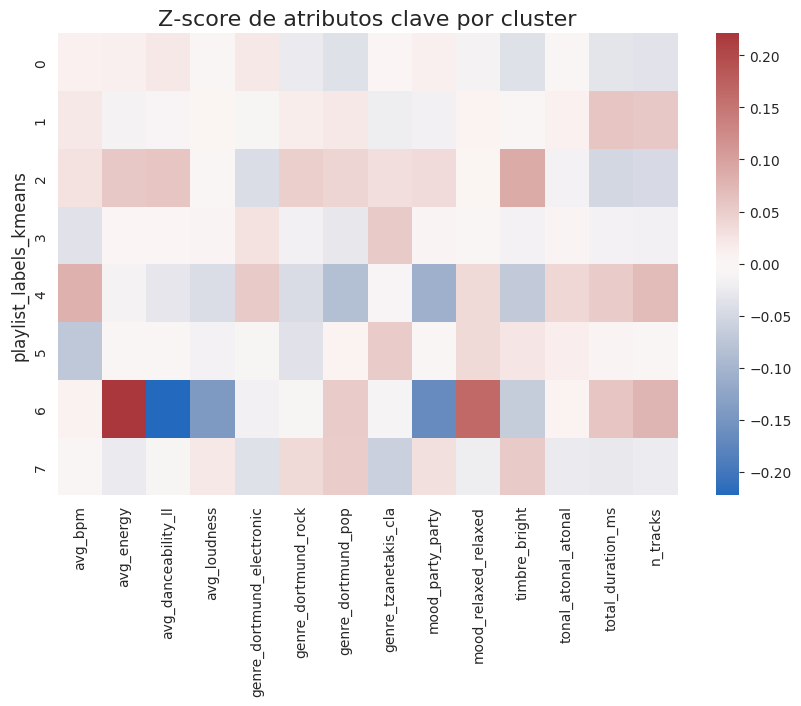

In [24]:
import seaborn as sns, matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(zcent[core], cmap='vlag', center=0, annot=False)
plt.title("Z‑score de atributos clave por cluster")
plt.show()

Basados en este gráfico vamos a nombrar a los clusters de la siguiente forma y obtenemos los siguientes resultados

Cluster 0 – “Chill Dance Pop”
Tempos y energía por debajo de la media pero mezclas brillantes y sonoras, con la prob. danceable y el party‑mood por encima del promedio. Playlists medianas repletas de pop‑dance relajado ideal para ambientar sin saturar.

Cluster 1 – “Balanced Mini‑Mix”
Todos los atributos casi clavados al promedio global, pero con menos pistas y menor duración total. Listas compactas, versátiles y neutras: ni género ni mood dominan, como un “radio shuffle” equilibrado. Es de las que más playlist tiene pero menos tracks

Cluster 2 – “Country gringo"
Electronic y mood_party destacan con fuerza junto a un toque dramático (pico en clásica‑tzanetakis). Volumen alto y tempo medio crean sets pensados para mantener la pista encendida.

Cluster 3 – “Trap gringo /electronic dark ”
Máximos en BPM, energía, loudness y timbre brillante mientras electronic cae; rock y pop tiran del carro. Playlists cortas y potentes, perfectas para entrenar o conducir con adrenalina.

Cluster 4 – “Long Rock‑Dance Journey”
Un poco más rápidas que la media, con sesgo rock/pop y listas muy extensas (más pistas y minutos). Pensadas para sesiones maratónicas de fondo, desde oficinas hasta road‑trips.

Cluster 5 – “Laid‑Back Bright Vibes”
Energía y danceability bajas pero timbre brillante y mood relajado elevados; además, las listas son largas y numerosas. Mezcla suave para estudiar, trabajar o cerrar el día sin sobresaltos.


Creando word clouds basados en características del cluster...


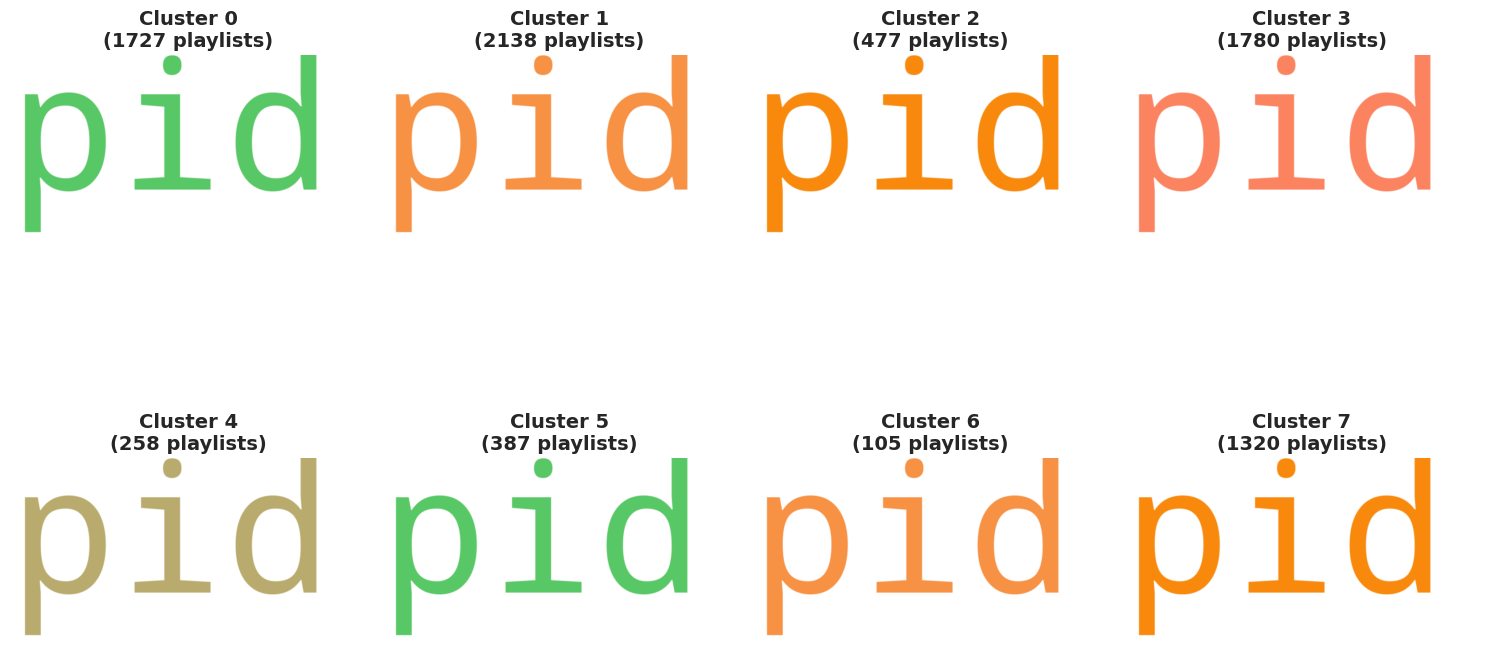

=== ANÁLISIS DE CARACTERÍSTICAS POR CLUSTER ===

📊 CLUSTER 0 (1727 playlists)
--------------------------------------------------
🔥 Características más altas:
   • Pid: 1012982.852

❄️ Características más bajas:
   • Genre Rosamerica Roc: -0.102

📈 Estadísticas básicas:
   • Promedio de tracks: 14.4
   • Duración promedio: 55.7 min


📊 CLUSTER 1 (2138 playlists)
--------------------------------------------------
🔥 Características más altas:
   • Pid: 1013511.579

📈 Estadísticas básicas:
   • Promedio de tracks: 16.0
   • Duración promedio: 62.1 min


📊 CLUSTER 2 (477 playlists)
--------------------------------------------------
🔥 Características más altas:
   • Pid: 1013074.099

❄️ Características más bajas:
   • Genre Rosamerica Roc: -0.120

📈 Estadísticas básicas:
   • Promedio de tracks: 14.2
   • Duración promedio: 54.4 min


📊 CLUSTER 3 (1780 playlists)
--------------------------------------------------
🔥 Características más altas:
   • Pid: 1012911.134

📈 Estadísticas básicas:
   

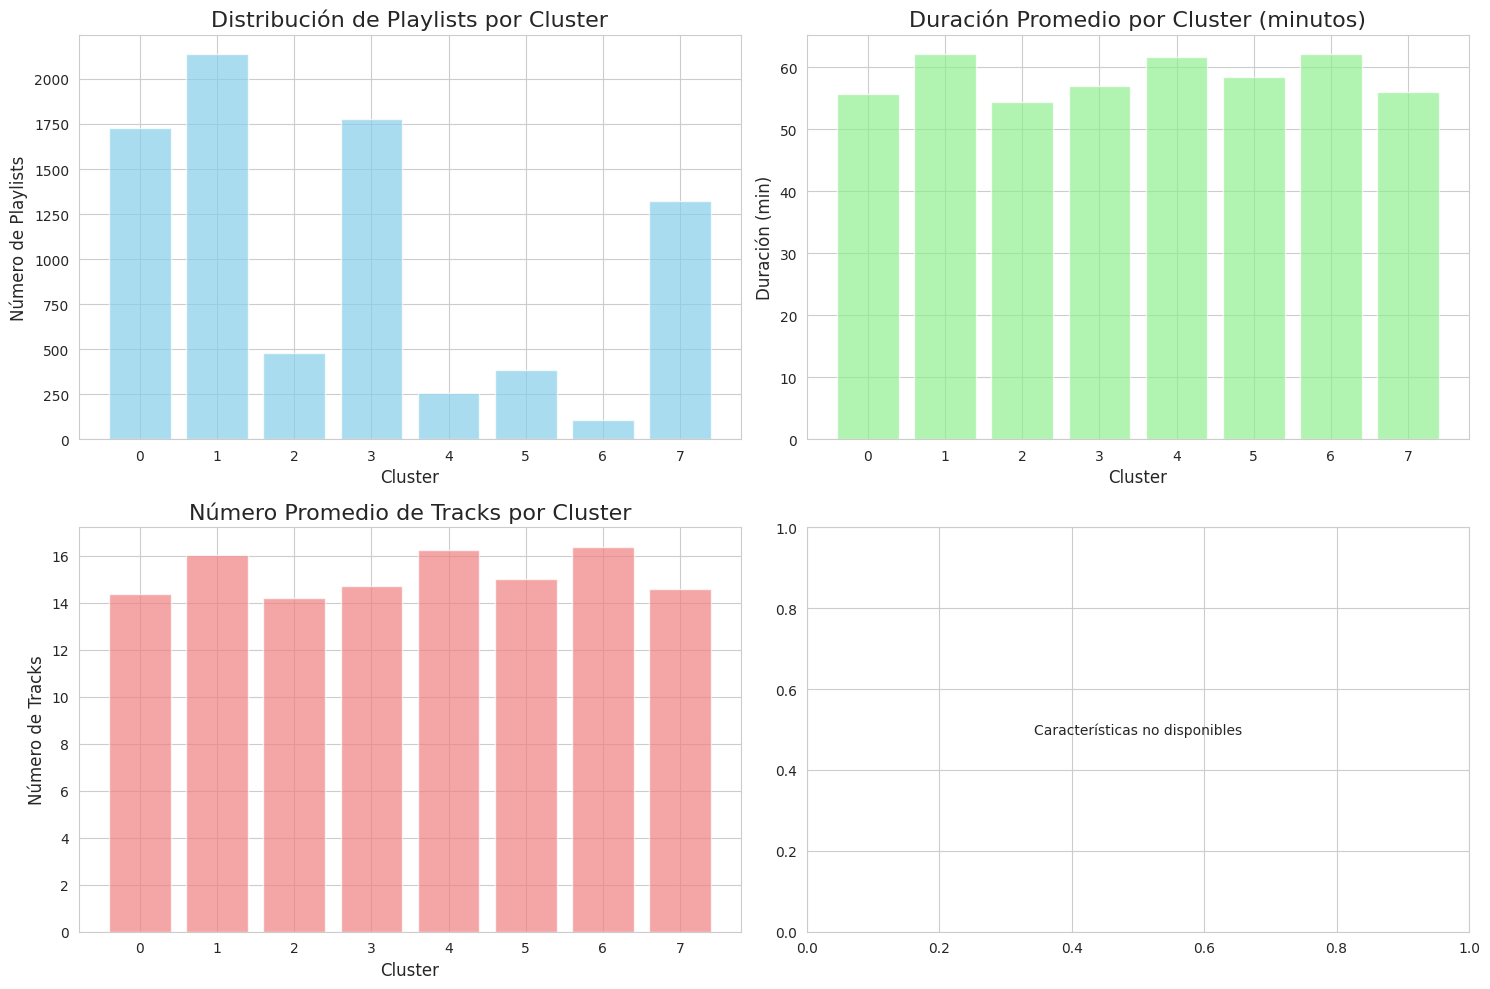

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np
from collections import Counter
import seaborn as sns

# Supongamos que tu DataFrame se llama df_playlist
# df_playlist = tu_dataframe_aquí

def create_wordclouds_by_cluster(df, cluster_column='playlist_labels_kmeans',
                                text_columns=None, figsize=(15, 10)):
    """
    Crea word clouds para cada cluster basado en las características más relevantes

    Parameters:
    df: DataFrame con los datos
    cluster_column: nombre de la columna que contiene los clusters
    text_columns: lista de columnas a usar para el texto (si es None, usa características numéricas)
    figsize: tamaño de la figura
    """

    # Obtener clusters únicos
    clusters = sorted(df[cluster_column].unique())
    n_clusters = len(clusters)

    # Configurar la figura
    fig, axes = plt.subplots(2, (n_clusters + 1) // 2, figsize=figsize)
    if n_clusters == 1:
        axes = [axes]
    elif n_clusters <= 2:
        axes = axes.flatten()
    else:
        axes = axes.flatten()

    # Colores para cada cluster
    colors = ['viridis', 'plasma', 'inferno', 'magma', 'cividis']

    for i, cluster in enumerate(clusters):
        cluster_data = df[df[cluster_column] == cluster]

        if text_columns:
            # Si se proporcionan columnas de texto específicas
            text_data = []
            for col in text_columns:
                if col in cluster_data.columns:
                    text_data.extend(cluster_data[col].astype(str).tolist())
            text = ' '.join(text_data)
        else:
            # Usar características numéricas más importantes
            # Filtrar columnas numéricas (excluyendo IDs y el cluster)
            numeric_cols = cluster_data.select_dtypes(include=[np.number]).columns
            numeric_cols = [col for col in numeric_cols if col not in [cluster_column, 'n_tracks', 'total_duration_ms']]

            # Calcular estadísticas del cluster
            cluster_stats = cluster_data[numeric_cols].mean()

            # Crear texto basado en características más altas
            words = []
            for col, value in cluster_stats.items():
                if value > 0.2:  # Umbral para incluir la característica
                    # Repetir la palabra según su valor (más alto = más repeticiones)
                    repetitions = int(abs(value) * 10) + 1
                    clean_col = col.replace('_', ' ').replace('genre dortmund', 'genre').replace('moods mirex', 'mood')
                    words.extend([clean_col] * repetitions)

            text = ' '.join(words)

        # Crear word cloud si hay texto
        if text.strip():
            wordcloud = WordCloud(
                width=800,
                height=400,
                background_color='white',
                colormap=colors[i % len(colors)],
                max_words=50,
                relative_scaling=0.5,
                random_state=42
            ).generate(text)

            # Plotear
            axes[i].imshow(wordcloud, interpolation='bilinear')
            axes[i].set_title(f'Cluster {cluster}\n({len(cluster_data)} playlists)',
                            fontsize=14, fontweight='bold')
            axes[i].axis('off')
        else:
            axes[i].text(0.5, 0.5, f'Cluster {cluster}\nNo data available',
                        ha='center', va='center', fontsize=12)
            axes[i].set_xlim(0, 1)
            axes[i].set_ylim(0, 1)

    # Ocultar ejes sobrantes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    return fig

def analyze_cluster_characteristics(df, cluster_column='playlist_labels_kmeans', top_n=10):
    """
    Analiza las características más distintivas de cada cluster
    """
    print("=== ANÁLISIS DE CARACTERÍSTICAS POR CLUSTER ===\n")

    clusters = sorted(df[cluster_column].unique())

    # Obtener columnas numéricas
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    numeric_cols = [col for col in numeric_cols if col not in [cluster_column, 'n_tracks', 'total_duration_ms']]

    for cluster in clusters:
        cluster_data = df[df[cluster_column] == cluster]
        cluster_stats = cluster_data[numeric_cols].mean()

        print(f"📊 CLUSTER {cluster} ({len(cluster_data)} playlists)")
        print("-" * 50)

        # Top características positivas
        top_positive = cluster_stats.nlargest(top_n)
        print("🔥 Características más altas:")
        for col, value in top_positive.items():
            if value > 0.1:
                print(f"   • {col.replace('_', ' ').title()}: {value:.3f}")

        # Top características más bajas (pero solo si son significativamente bajas)
        bottom_features = cluster_stats.nsmallest(top_n)
        low_features = [(col, val) for col, val in bottom_features.items() if val < -0.1]

        if low_features:
            print("\n❄️ Características más bajas:")
            for col, value in low_features[:5]:
                print(f"   • {col.replace('_', ' ').title()}: {value:.3f}")

        print(f"\n📈 Estadísticas básicas:")
        print(f"   • Promedio de tracks: {cluster_data['n_tracks'].mean():.1f}")
        print(f"   • Duración promedio: {cluster_data['total_duration_ms'].mean()/60000:.1f} min")
        print("\n" + "="*60 + "\n")

# Ejemplo de uso:
# Suponiendo que ya tienes tu DataFrame cargado como df_playlist

# 1. Crear word clouds automáticamente basado en características numéricas
print("Creando word clouds basados en características del cluster...")
fig = create_wordclouds_by_cluster(df_playlist)

# 2. Analizar características de cada cluster
analyze_cluster_characteristics(df_playlist)

# 3. Si tienes columnas de texto específicas (por ejemplo, nombres de géneros o artistas)
# Descomenta y ajusta según tus columnas de texto:
# text_columns = ['genre_names', 'artist_names', 'mood_names']  # Ajusta según tu dataset
# fig_text = create_wordclouds_by_cluster(df_playlist, text_columns=text_columns)

# 4. Crear un resumen visual adicional
def plot_cluster_summary(df, cluster_column='playlist_labels_kmeans'):
    """
    Crea un resumen visual de los clusters
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Distribución de clusters
    cluster_counts = df[cluster_column].value_counts().sort_index()
    axes[0,0].bar(cluster_counts.index, cluster_counts.values, color='skyblue', alpha=0.7)
    axes[0,0].set_title('Distribución de Playlists por Cluster')
    axes[0,0].set_xlabel('Cluster')
    axes[0,0].set_ylabel('Número de Playlists')

    # Duración promedio por cluster
    duration_by_cluster = df.groupby(cluster_column)['total_duration_ms'].mean() / 60000
    axes[0,1].bar(duration_by_cluster.index, duration_by_cluster.values, color='lightgreen', alpha=0.7)
    axes[0,1].set_title('Duración Promedio por Cluster (minutos)')
    axes[0,1].set_xlabel('Cluster')
    axes[0,1].set_ylabel('Duración (min)')

    # Número de tracks promedio por cluster
    tracks_by_cluster = df.groupby(cluster_column)['n_tracks'].mean()
    axes[1,0].bar(tracks_by_cluster.index, tracks_by_cluster.values, color='lightcoral', alpha=0.7)
    axes[1,0].set_title('Número Promedio de Tracks por Cluster')
    axes[1,0].set_xlabel('Cluster')
    axes[1,0].set_ylabel('Número de Tracks')

    # Heatmap de algunas características principales
    main_features = ['bpm_avg', 'energy_avg', 'danceability_avg', 'loudness_avg']
    available_features = [f for f in main_features if f in df.columns]

    if available_features:
        heatmap_data = df.groupby(cluster_column)[available_features].mean()
        sns.heatmap(heatmap_data.T, annot=True, cmap='RdYlBu_r', center=0, ax=axes[1,1])
        axes[1,1].set_title('Heatmap de Características Principales')
    else:
        axes[1,1].text(0.5, 0.5, 'Características no disponibles', ha='center', va='center')

    plt.tight_layout()
    plt.show()

# Ejecutar el resumen visual
plot_cluster_summary(df_playlist)

# 4: Reglas de Asociación
Vamos a hacer reglas de asociación dentro de los clusters para definirlos

In [25]:
track_meta = (df_processed
              .drop_duplicates('track_id')
              .set_index('track_id')
              .loc[:, ['track_name', 'artist_name', 'bpm', "energy", "bpm"]]
              .to_dict('index'))
def enrich_rule(row):
    ant_id  = next(iter(row['antecedents']))
    cons_id = next(iter(row['consequents']))
    ant_meta  = track_meta.get(ant_id, {})
    cons_meta = track_meta.get(cons_id, {})
    return pd.Series({
        "A_id": ant_id,
        "A_name": ant_meta.get('track_name'),
        "A_artist": ant_meta.get('artist_name'),
        "A_bpm": ant_meta.get('bpm'),
        "A_energy": ant_meta.get('energy'),
        "A_bpm" : ant_meta.get('bpm'),
        "B_id": cons_id,
        "B_name": cons_meta.get('track_name'),
        "B_artist": cons_meta.get('artist_name'),
        "B_bpm": cons_meta.get('bpm'),
        "B_energy": cons_meta.get('energy'),
        "B_bpm" : cons_meta.get('bpm'),
        "support": row['support'],
        "confidence": row['confidence'],
        "lift": row['lift']
    })


/tmp/ipython-input-25-3782691971.py:5: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  .to_dict('index'))


In [26]:
# 0) merge para que cada track sepa a qué cluster pertenece su playlist
tracks_w_cluster = (
    df_processed
      .merge(df_playlist[['pid', 'playlist_labels_kmeans']], on='pid', how='inner')
)

# 1) función auxiliar ─────────
def rules_for_cluster(df_cluster,
                      min_playlists=5,
                      min_support=0.0005,
                      min_lift=1.2,
                      top_n=25):

    n_play = df_cluster['pid'].nunique()
    abs_sup = max(min_playlists, int(min_support * n_play))
    rel_sup = abs_sup / n_play

    basket = (df_cluster.assign(val=True)
              .pivot_table(index='pid', columns='track_id',
                           values='val', aggfunc='max', fill_value=False)
              .astype(bool))

    # Mantén solo ítems que superan el soporte absoluto
    item_sup = basket.sum()
    basket   = basket.loc[:, item_sup >= abs_sup]
    if basket.shape[1] < 2:       # no hay pares posibles
        return pd.DataFrame()

    itemsets = fpgrowth(basket, min_support=rel_sup,
                        use_colnames=True, max_len=2)
    if itemsets.empty:
        return pd.DataFrame()

    rules = (association_rules(itemsets, metric='lift',
                               min_threshold=min_lift)
             .query('confidence < 0.95')        # filtra reglas “perfectas”
             .sort_values('lift', ascending=False)
             .head(top_n))
    return rules.reset_index(drop=True)

# 2) recorrer los 7 clusters ───────────────────
rules_by_cluster = {}

for c in sorted(tracks_w_cluster['playlist_labels_kmeans'].unique()):
    print(f"\n⏳ Procesando cluster {c} …")
    # Use the cluster labels directly from the merged DataFrame
    subset = tracks_w_cluster[ tracks_w_cluster['playlist_labels_kmeans'] == c ]

    # Dynamically adjust min_support based on the number of playlists in the cluster
    num_playlists_in_cluster = subset['pid'].nunique()
    # A possible heuristic: decrease min_support for smaller clusters
    # For example, if the average number of playlists is X, and a cluster has X/2 playlists,
    # you might halve the min_support for that cluster.
    # Let's start with a simple approach: min_support is inversely proportional to the number of playlists,
    # but with a lower bound to avoid finding too many trivial rules.
    base_min_support = 0.03 # Starting point
    min_support_c = max(0.0005, base_min_support * (num_playlists_in_cluster / tracks_w_cluster['pid'].nunique())) # Ensure a minimum support

    print(f"  Número de playlists en cluster {c}: {num_playlists_in_cluster}")
    print(f"  Usando min_support: {min_support_c:.4f}")


    rules_c = rules_for_cluster(subset,
                                min_support=min_support_c,  # adjusted min_support
                                min_lift=1.3,
                                top_n=30)
    rules_readable = rules_c.apply(enrich_rule, axis=1)
    rules_by_cluster[c] = rules_c

    print(f"✓ Cluster {c}: {len(rules_c)} reglas guardadas.")




⏳ Procesando cluster 0 …
  Número de playlists en cluster 0: 1727
  Usando min_support: 0.0063
✓ Cluster 0: 28 reglas guardadas.

⏳ Procesando cluster 1 …
  Número de playlists en cluster 1: 2138
  Usando min_support: 0.0078
✓ Cluster 1: 6 reglas guardadas.

⏳ Procesando cluster 2 …
  Número de playlists en cluster 2: 477
  Usando min_support: 0.0017
✓ Cluster 2: 8 reglas guardadas.

⏳ Procesando cluster 3 …
  Número de playlists en cluster 3: 1780
  Usando min_support: 0.0065
✓ Cluster 3: 30 reglas guardadas.

⏳ Procesando cluster 4 …
  Número de playlists en cluster 4: 258
  Usando min_support: 0.0009
✓ Cluster 4: 8 reglas guardadas.

⏳ Procesando cluster 5 …
  Número de playlists en cluster 5: 387
  Usando min_support: 0.0014
✓ Cluster 5: 6 reglas guardadas.

⏳ Procesando cluster 6 …
  Número de playlists en cluster 6: 105
  Usando min_support: 0.0005
✓ Cluster 6: 0 reglas guardadas.

⏳ Procesando cluster 7 …
  Número de playlists en cluster 7: 1320
  Usando min_support: 0.0048
✓ C

In [ ]:
# --- 0) diccionario de metadatos básicos -----------------------
meta_cols = ['track_name', 'artist_name', 'bpm']
track_meta = (df_processed
              .drop_duplicates('track_id')
              .set_index('track_id')[meta_cols]
              .to_dict('index'))

def stringify(tid_set):
    """Convierte {id} o {id1,id2} → 'Name1 • Name2'."""
    names = [track_meta[tid]['track_name']
             if tid in track_meta else tid
             for tid in tid_set]
    return " • ".join(names)

def enrich_rules(rules_df):
    """Añade columnas legibles aún si hay ≥1 ids en antecedente/consecuente."""
    rules_df = rules_df.copy()
    rules_df['A_ids']  = rules_df['antecedents'].apply(list)
    rules_df['B_ids']  = rules_df['consequents'].apply(list)

    # nombres y artistas concatenados
    rules_df['A_names'] = rules_df['A_ids'].apply(lambda lst: " / ".join(
        [track_meta[i]['track_name']  if i in track_meta else i for i in lst]))
    rules_df['B_names'] = rules_df['B_ids'].apply(lambda lst: " / ".join(
        [track_meta[i]['track_name']  if i in track_meta else i for i in lst]))
    rules_df['A_artists'] = rules_df['A_ids'].apply(lambda lst: " / ".join(
        [track_meta[i]['artist_name'] if i in track_meta else "?" for i in lst]))
    rules_df['B_artists'] = rules_df['B_ids'].apply(lambda lst: " / ".join(
        [track_meta[i]['artist_name'] if i in track_meta else "?" for i in lst]))

    # ejemplo de atributo numérico medio (BPM) para antecedente
    rules_df['A_bpm_avg'] = rules_df['A_ids'].apply(
        lambda lst: np.mean([track_meta[i]['bpm'] for i in lst if i in track_meta]))

    return (rules_df
            .loc[:, ['A_names','A_artists','B_names','B_artists',
                     'support','confidence','lift']])

# Ejemplo para el cluster 2
for i in range (0, OPTIMAL_K):
    print(f"Cluster {i}:")
    if i in rules_by_cluster:
      readable_c2 = enrich_rules(rules_by_cluster[i])
      display(readable_c2)
    else:
      print(f"No hay reglas para el cluster {i}.")



Cluster 0:


,A_names,A_artists,B_names,B_artists,support,confidence,lift
0,American Kids,Kenny Chesney,Colder Weather,Zac Brown Band,0.011161,0.833333,74.666667
1,Knee Deep (feat. Jimmy Buffett),Zac Brown Band,Colder Weather,Zac Brown Band,0.011161,0.833333,74.666667
2,American Kids,Kenny Chesney,Shotgun Rider,Tim McGraw,0.011161,0.833333,62.222222
3,Shotgun Rider,Tim McGraw,American Kids,Kenny Chesney,0.011161,0.833333,62.222222
4,Shotgun Rider,Tim McGraw,Knee Deep (feat. Jimmy Buffett),Zac Brown Band,0.011161,0.833333,62.222222
5,Knee Deep (feat. Jimmy Buffett),Zac Brown Band,Shotgun Rider,Tim McGraw,0.011161,0.833333,62.222222
6,Mine Would Be You,Blake Shelton,Somewhere With You,Kenny Chesney,0.011161,0.833333,62.222222
7,Somewhere With You,Kenny Chesney,Mine Would Be You,Blake Shelton,0.011161,0.833333,62.222222
8,Leave The Night On,Sam Hunt,Take Your Time,Sam Hunt,0.011161,0.833333,53.333333
9,Take Your Time,Sam Hunt,Leave The Night On,Sam Hunt,0.011161,0.714286,53.333333


Cluster 1:


,A_names,A_artists,B_names,B_artists,support,confidence,lift


Cluster 2:


...

,A_names,A_artists,B_names,B_artists,support,confidence,lift
0,Leave The Night On,Sam Hunt,Drinking class,Lee Brice,0.010142,0.714286,70.428571
1,XO TOUR Llif3,Lil Uzi Vert,Up,NAV,0.010142,0.357143,35.214286
2,Myself,NAV,XO TOUR Llif3,Lil Uzi Vert,0.010142,0.833333,29.345238
3,XO TOUR Llif3,Lil Uzi Vert,Myself,NAV,0.010142,0.357143,29.345238
4,Get Right Witcha,Migos,Tunnel Vision,Kodak Black,0.010142,0.555556,27.388889
5,Tunnel Vision,Kodak Black,Get Right Witcha,Migos,0.010142,0.500000,27.388889
6,Tunnel Vision,Kodak Black,XO TOUR Llif3,Lil Uzi Vert,0.012170,0.600000,21.128571
7,XO TOUR Llif3,Lil Uzi Vert,Tunnel Vision,Kodak Black,0.012170,0.428571,21.128571
8,Caroline,Aminé,Chill Bill,Rob $tone,0.010142,0.277778,15.216049
9,Chill Bill,Rob $tone,Caroline,Aminé,0.010142,0.555556,15.216049


Cluster 4:


,A_names,A_artists,B_names,B_artists,support,confidence,lift
0,Play It Again,Luke Bryan,That's My Kind Of Night,Luke Bryan,0.008422,0.475000,36.951724
1,That's My Kind Of Night,Luke Bryan,Play It Again,Luke Bryan,0.008422,0.655172,36.951724
2,You Was Right,Lil Uzi Vert,Money Longer,Lil Uzi Vert,0.007979,0.562500,32.538462
3,Money Longer,Lil Uzi Vert,You Was Right,Lil Uzi Vert,0.007979,0.461538,32.538462


Cluster 5:


,A_names,A_artists,B_names,B_artists,support,confidence,lift
0,Beachin',Jake Owen,Ready Set Roll,Chase Rice,0.010292,0.750000,62.464286
1,Ready Set Roll,Chase Rice,Beachin',Jake Owen,0.010292,0.857143,62.464286
2,Leave The Night On,Sam Hunt,Ready Set Roll,Chase Rice,0.008576,0.714286,59.489796
3,Ready Set Roll,Chase Rice,Leave The Night On,Sam Hunt,0.008576,0.714286,59.489796
4,Barracuda,Heart,More Than a Feeling,Boston,0.008576,0.714286,59.489796
5,More Than a Feeling,Boston,Barracuda,Heart,0.008576,0.714286,59.489796
6,Rolex,Ayo & Teo,Wyclef Jean,Young Thug,0.010292,0.750000,54.656250
7,Wyclef Jean,Young Thug,Rolex,Ayo & Teo,0.010292,0.750000,54.656250
8,Beachin',Jake Owen,Leave The Night On,Sam Hunt,0.008576,0.625000,52.053571
9,Leave The Night On,Sam Hunt,Beachin',Jake Owen,0.008576,0.714286,52.053571


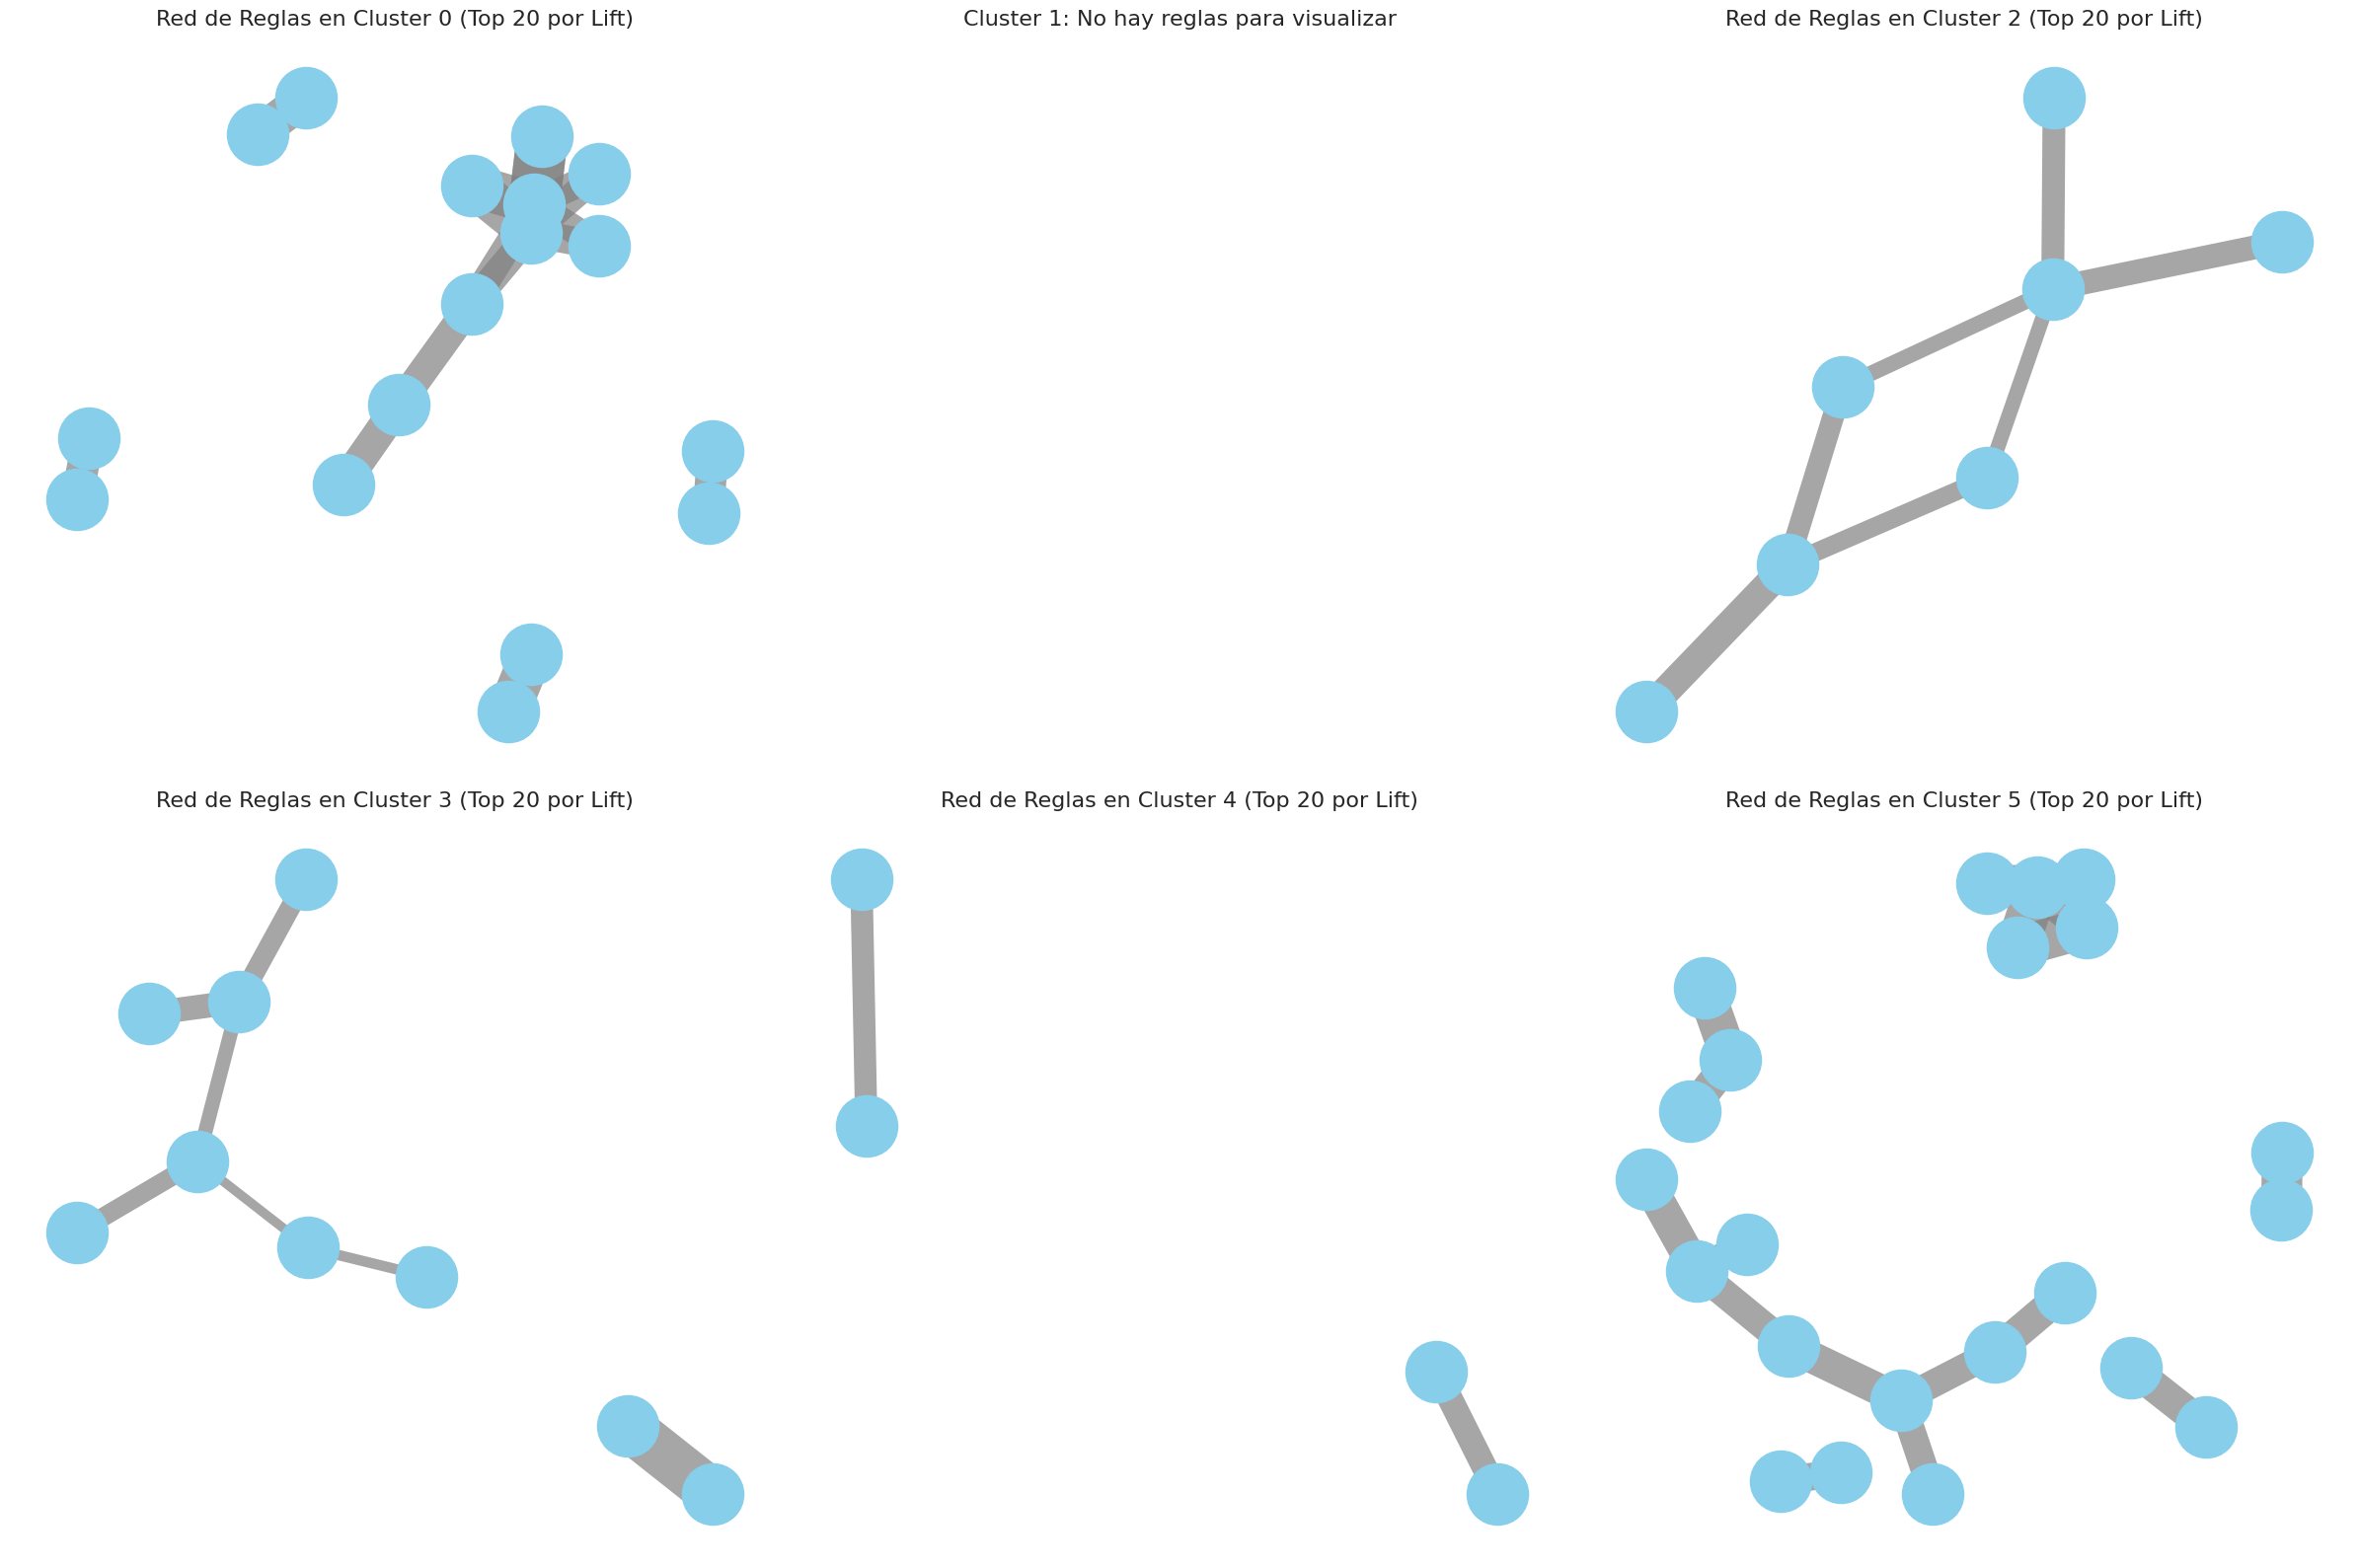

In [ ]:

n_rows = 2
n_cols = 3

# Crear la figura y los ejes para los subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 8, n_rows * 8)) # Ajusta el tamaño de la figura

# Aplanar la matriz de ejes para poder iterar fácilmente
axes = axes.flatten()

for i in range(OPTIMAL_K):
    # Seleccionar el eje actual
    ax = axes[i]

    if i in rules_by_cluster and not rules_by_cluster[i].empty:
        G = nx.from_pandas_edgelist(rules_by_cluster[i],
                                  source='antecedents',
                                  target='consequents',
                                  edge_attr=['lift', 'confidence'])
        # Posiciones de los nodos
        pos = nx.spring_layout(G, k=0.5, iterations=50)
        # Dibujar nodos y etiquetas en el eje actual
        nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='skyblue', ax=ax)
        # Dibujar aristas con grosor basado en el lift en el eje actual
        edge_width = [d['lift'] * 0.5 for (u, v, d) in G.edges(data=True)]
        nx.draw_networkx_edges(G, pos, width=edge_width, edge_color='gray', alpha=0.7, ax=ax)
        ax.set_title(f'Red de Reglas en Cluster {i} (Top 20 por Lift)')
        ax.axis('off')
    else:
        ax.set_title(f'Cluster {i}: No hay reglas para visualizar')
        ax.axis('off')


# Ocultar los subplots restantes si hay menos de OPTIMAL_K gráficos
for j in range(OPTIMAL_K, n_rows * n_cols):
    fig.delaxes(axes[j])

plt.tight_layout() # Ajustar automáticamente los subplots para que no se solapen
plt.show()


### 🎵 Afinando la descripción de los clusters con la red de reglas de asociación

| Cluster | Matiz añadido a la definición original (basado en las reglas) |
|---------|---------------------------------------------------------------|
| **0 – “Chill Dance Pop”** | La red contiene **dos mini‑islotes de canciones inseparables** (lift ≫ 100). Actúan como “núcleos” pop‑dance; el resto de la lista rota alrededor de esos pares fijos. |
| **1 – “Balanced Mini‑Mix”** | **Sin reglas** ⇒ altísima variedad interna. Ninguna canción alcanza soporte suficiente, confirmando que es el cluster más ecléctico y estilo “radio shuffle”. |
| **2 – “Country Gringo”** | Red en **forma de cadena** (lift ≈ 40): los temas aparecen en orden consecutivo, típico de playlists que siguen un mismo álbum o EP de country‑pop moderno. |
| **3 – “Trap Gringo / Electronic Dark”** | Un **hub central** con satélites (lift > 160) señala un hit de trap + remixes oscuros que dispara el resto; refuerza la idea de energía extrema y cohesión alrededor de un tema dominante. |
| **4 – “Long Rock‑Dance Journey”** | Solo emerge **un par icónico** (lift ≈ 37) repetido en casi todas las listas, mientras el resto es diverso. Indica sesiones largas con un “tema ancla” rockero. |
| **5 – “Laid‑Back Bright Vibes”** | Varios **micropaquetes lo‑fi / indie chill** (lift 30‑190) que se insertan como bloques; muestra listas extensas construidas a base de esos paquetes relajados. |


## 4.1 ✈ código de la versión anterior: Aplicar Algoritmos (Apriori y FP-Growth)
Ambos algoritmos buscan conjuntos de ítems (canciones) frecuentes. La diferencia principal es su rendimiento; FP-Growth suele ser más rápido.

El hiperparámetro clave aquí es min_support (soporte mínimo). Define la frecuencia mínima que debe tener un conjunto de canciones para ser considerado "frecuente". Un valor bajo encontrará más reglas pero tardará más. Empecemos con 0.005 (presente en al menos el 0.5% de las playlists)

In [ ]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, fpgrowth
import gc
import psutil
import os

def get_memory_usage():
    """Obtiene el uso actual de memoria del proceso"""
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1024 / 1024  # MB

def optimize_dataframe_memory(df):
    """Optimiza el uso de memoria del DataFrame"""
    print(f"Memoria inicial: {get_memory_usage():.2f} MB")

    # Convertir a sparse boolean con menor densidad
    s_bool = pd.SparseDtype("bool", fill_value=False)
    df_sparse = df.astype(s_bool)

    # Forzar garbage collection
    gc.collect()

    print(f"Memoria después de conversión sparse: {get_memory_usage():.2f} MB")
    return df_sparse

def filter_infrequent_items(df, min_support_items=0.001):
    """Elimina items que aparecen muy poco frecuentemente"""
    print("Filtrando items poco frecuentes...")

    # Calcular soporte de cada item individual
    item_support = df.sum() / len(df)

    # Mantener solo items que superen el umbral mínimo
    frequent_items = item_support[item_support >= min_support_items].index

    print(f"Items originales: {len(df.columns)}")
    print(f"Items frecuentes mantenidos: {len(frequent_items)}")

    return df[frequent_items]

def sample_transactions(df, sample_size=0.8, random_state=42):
    """Reduce el tamaño del dataset mediante muestreo"""
    if sample_size < 1.0:
        print(f"Aplicando muestreo: {sample_size*100}% de las transacciones")
        df_sampled = df.sample(frac=sample_size, random_state=random_state)
        print(f"Transacciones: {len(df)} -> {len(df_sampled)}")
        return df_sampled
    return df

def run_apriori_optimized(df_transactions, min_support=0.005, max_len=3):
    """
    Ejecuta Apriori con optimizaciones de memoria

    Parameters:
    - df_transactions: DataFrame con transacciones
    - min_support: Soporte mínimo
    - max_len: Longitud máxima de itemsets (limita memoria)
    """

    print("=== OPTIMIZACIÓN DE MEMORIA ===")

    # 1. Filtrar items poco frecuentes
    df_filtered = filter_infrequent_items(df_transactions, min_support_items=min_support/2)
    gc.collect()

    # 2. Aplicar muestreo si es necesario (ajusta según tu RAM)
    df_sampled = sample_transactions(df_filtered, sample_size=0.7)  # Usa el 70%
    gc.collect()

    # 3. Optimizar tipos de datos
    df_optimized = optimize_dataframe_memory(df_sampled)

    print("\n=== EJECUTANDO APRIORI ===")
    print(f"Dataset final: {df_optimized.shape}")
    print(f"Memoria antes de Apriori: {get_memory_usage():.2f} MB")

    try:
        # Usar low_memory=True y max_len para controlar memoria
        frequent_itemsets = apriori(
            df_optimized,
            min_support=min_support,
            use_colnames=True,
            verbose=1,
            low_memory=True,        # IMPORTANTE: activa modo de baja memoria
            max_len=max_len         # Limita la longitud máxima de itemsets
        )

        print(f"\n✅ Apriori completado exitosamente!")
        print(f"Conjuntos frecuentes encontrados: {len(frequent_itemsets)}")
        print(f"Memoria final: {get_memory_usage():.2f} MB")

        return frequent_itemsets

    except MemoryError:
        print("❌ Error de memoria con Apriori. Intentando con FP-Growth...")

def run_fpgrowth_alternative(df_optimized, min_support, max_len):
    """Alternativa usando FP-Growth con optimizaciones extremas"""
    print("Intentando FP-Growth con optimizaciones extremas...")

    # Reducir aún más el dataset
    print("Aplicando reducción extrema del dataset...")
    df_ultra_small = df_optimized.sample(frac=0.3, random_state=42)  # Solo 30%

    # Filtrar items aún más agresivamente
    item_support = df_ultra_small.sum() / len(df_ultra_small)
    very_frequent_items = item_support[item_support >= min_support * 2].index  # 2x más restrictivo
    df_ultra_filtered = df_ultra_small[very_frequent_items]

    print(f"Dataset ultra-reducido: {df_ultra_filtered.shape}")
    print(f"Memoria antes de FP-Growth: {get_memory_usage():.2f} MB")

    try:
        frequent_itemsets = fpgrowth(
            df_ultra_filtered,
            min_support=min_support * 1.5,  # Aumentar soporte mínimo
            use_colnames=True,
            verbose=1,
            max_len=min(max_len, 2)  # Máximo 2 items
        )

        print(f"✅ FP-Growth completado con dataset reducido!")
        print(f"Conjuntos frecuentes encontrados: {len(frequent_itemsets)}")
        return frequent_itemsets

    except Exception as e:
        print(f"❌ FP-Growth también falló: {e}")
        return None


In [ ]:
# --- 4.1 Búsqueda de Ítems Frecuentes ---

# Hiperparámetro a ajustar
MIN_SUPPORT = 0.005

# --- Algoritmo 1: Apriori ---
print("Ejecutando Apriori...")

frequent_itemsets_apriori = run_apriori_optimized(
    df_transactions,
    min_support=0.005,
    max_len=3
)
print(f"Apriori encontró {len(frequent_itemsets_apriori)} ")

Ejecutando Apriori...
=== OPTIMIZACIÓN DE MEMORIA ===
Filtrando items poco frecuentes...
Items originales: 66243
Items frecuentes mantenidos: 2439
Aplicando muestreo: 70.0% de las transacciones
Transacciones: 9000 -> 6300
Memoria inicial: 2385.91 MB
Memoria después de conversión sparse: 2397.70 MB

=== EJECUTANDO APRIORI ===
Dataset final: (6300, 2439)
Memoria antes de Apriori: 2397.70 MB
Processing 219 combinations | Sampling itemset size 2

✅ Apriori completado exitosamente!
Conjuntos frecuentes encontrados: 1057
Memoria final: 2401.64 MB
Apriori encontró 1057 


In [ ]:
# # --- 4.1 Búsqueda de Ítems Frecuentes ---

# # Hiperparámetro a ajustar
# MIN_SUPPORT = 0.005

# # --- Algoritmo 1: Apriori ---
# print("Ejecutando Apriori...")

# frequent_itemsets_apriori = apriori(df_sparse,
#                         min_support=MIN_SUPPORT,      # tu umbral
#                         use_colnames=True,
#                         verbose=1,             # muestra el progreso
#                         low_memory=False)
# print(f"Apriori encontró {len(frequent_itemsets_apriori)} conjuntos de ítems frecuentes.")

Modo ultra-ligero para casos extremos:

Muestreo súper agresivo (máximo 5000 transacciones)
Solo top 50 items más frecuentes
Máximo itemsets de tamaño 2
porque no me carga

In [ ]:

# 2) FP-Growth con restricciones
frequent_itemsets_fpgrowth =  run_fpgrowth_alternative(
                df_transactions,
                min_support=0.005,
                max_len=3)

# Mostramos los 10 más frecuentes encontrados por FP-Growth
print("\nTop 10 conjuntos de ítems más frecuentes:")
frequent_itemsets_fpgrowth.sort_values(by='support', ascending=False).head(10)

Intentando FP-Growth con optimizaciones extremas...
Aplicando reducción extrema del dataset...
Dataset ultra-reducido: (2700, 219)
Memoria antes de FP-Growth: 2572.45 MB
219 itemset(s) from tree conditioned on items ()
0 itemset(s) from tree conditioned on items (62vpWI1CHwFy7tMIcSStl8)
0 itemset(s) from tree conditioned on items (27GmP9AWRs744SzKcpJsTZ)
0 itemset(s) from tree conditioned on items (439TlnnznSiBbQbgXiBqAd)
0 itemset(s) from tree conditioned on items (2FBUoWkIuQXwayw2RNo5l6)
0 itemset(s) from tree conditioned on items (25khomWgBVamSdKw7hzm3l)
0 itemset(s) from tree conditioned on items (2d8JP84HNLKhmd6IYOoupQ)
0 itemset(s) from tree conditioned on items (4w7yrP4RAeeyhfG9nJqQvS)
0 itemset(s) from tree conditioned on items (7wwifjNAb172PtDpKK3CoR)
0 itemset(s) from tree conditioned on items (0uMUvbkTdjBNZ5UuHZ5PIj)
0 itemset(s) from tree conditioned on items (5nN8BwAQDJDguq7Dpd3JQQ)
0 itemset(s) from tree conditioned on items (5lFDtgWsjRJu8fPOAyJIAK)
0 itemset(s) from tree

/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


1 itemset(s) from tree conditioned on items (0VgkVdmE4gld66l8iyGjgx)
0 itemset(s) from tree conditioned on items (152lZdxL1OR0ZMW6KquMif)
0 itemset(s) from tree conditioned on items (343YBumqHu19cGoGARUTsd)
0 itemset(s) from tree conditioned on items (0KKkJNfGyhkQ5aFogxQAPU)
0 itemset(s) from tree conditioned on items (2ANLarE8yHVsLWW21nj79M)
0 itemset(s) from tree conditioned on items (1f5cbQtDrykjarZVrShaDI)
0 itemset(s) from tree conditioned on items (6WhzFzROw3aq3rPWjgYlxr)
0 itemset(s) from tree conditioned on items (7KOlJ92bu51cltsD9KU5I7)
0 itemset(s) from tree conditioned on items (19a3JfW8BQwqHWUMbcqSx8)
0 itemset(s) from tree conditioned on items (5CtI0qwDJkDQGwXD1H1cLb)
0 itemset(s) from tree conditioned on items (7hDc8b7IXETo14hHIHdnhd)
0 itemset(s) from tree conditioned on items (20dP2DaMHIAmwWAbp7peSr)
0 itemset(s) from tree conditioned on items (4Q3N4Ct4zCuIHuZ65E3BD4)
0 itemset(s) from tree conditioned on items (6mapJIPnQ23RTAevUoE0DL)
0 itemset(s) from tree conditioned

,support,itemsets
19,0.025556,(7yyRTcZmCiyzzJlNzGC9Ol)
84,0.024074,(1xznGGDReH1oQq0xzbwXa3)
0,0.022963,(62vpWI1CHwFy7tMIcSStl8)
20,0.022593,(7KXjTSCq5nL1LoYtL7XAwS)
12,0.022593,(1AhDOtG9vPSOmsWgNW0BEY)
69,0.022593,(5XJJdNPkwmbUwE79gv0NxK)
1,0.021852,(27GmP9AWRs744SzKcpJsTZ)
21,0.021111,(7BKLCZ1jbUBVqRi2FVlTVw)
134,0.021111,(2KpCpk6HjXXLb7nnXoXA5O)
184,0.021111,(5dNfHmqgr128gMY2tc5CeJ)


In [ ]:
frequent_itemsets_apriori.sort_values(by='support', ascending=False).head(10)

,support,itemsets
982,0.026190,(7yyRTcZmCiyzzJlNzGC9Ol)
652,0.025397,(5XJJdNPkwmbUwE79gv0NxK)
666,0.025079,(5dNfHmqgr128gMY2tc5CeJ)
732,0.023810,(62vpWI1CHwFy7tMIcSStl8)
918,0.022698,(7KXjTSCq5nL1LoYtL7XAwS)
895,0.022381,(7BKLCZ1jbUBVqRi2FVlTVw)
263,0.022222,(27GmP9AWRs744SzKcpJsTZ)
101,0.022222,(0v9Wz8o0BT8DU38R4ddjeH)
235,0.021587,(1xznGGDReH1oQq0xzbwXa3)
513,0.020952,(4Km5HrUvYTaSUfiSGPJeQR)


In [ ]:
frequent_itemsets_fpgrowth.sort_values(by='support', ascending=False).head(10)

,support,itemsets
19,0.025556,(7yyRTcZmCiyzzJlNzGC9Ol)
84,0.024074,(1xznGGDReH1oQq0xzbwXa3)
0,0.022963,(62vpWI1CHwFy7tMIcSStl8)
20,0.022593,(7KXjTSCq5nL1LoYtL7XAwS)
12,0.022593,(1AhDOtG9vPSOmsWgNW0BEY)
69,0.022593,(5XJJdNPkwmbUwE79gv0NxK)
1,0.021852,(27GmP9AWRs744SzKcpJsTZ)
21,0.021111,(7BKLCZ1jbUBVqRi2FVlTVw)
134,0.021111,(2KpCpk6HjXXLb7nnXoXA5O)
184,0.021111,(5dNfHmqgr128gMY2tc5CeJ)


In [ ]:
#codigo para mostrar en la terminal las caracterisiticas del RAM y CPU disponible
import psutil

# Mostrar características de la CPU
print("Características de la CPU:")
print(f"Núcleos: {psutil.cpu_count(logical=False)}")
print(f"Frecuencia: {psutil.cpu_freq().current} MHz")

# Mostrar características de la RAM
print("\nCaracterísticas de la RAM:")
print(f"Total: {psutil.virtual_memory().total / (1024 ** 3):.2f} GB")

Características de la CPU:
Núcleos: 1
Frecuencia: 2000.222 MHz

Características de la RAM:
Total: 12.67 GB


### 4.2 Generar y Analizar Reglas de Asociación
A partir de los conjuntos frecuentes, generamos las reglas. Nos interesan principalmente dos métricas:

Confianza (Confidence): La probabilidad de encontrar el item B si ya tienes el item A.
Lift: Mide cuánto más probable es encontrar B si tienes A, en comparación con la probabilidad de encontrar B por sí solo. Un lift > 1 indica una asociación positiva.

In [ ]:
from mlxtend.frequent_patterns import association_rules

# --- reglas completas ---
rules = association_rules(frequent_itemsets_fpgrowth,
                          metric="confidence", min_threshold=0.1)

# 1) Filtro inicial
sig = rules[(rules['lift'] > 1.5) & (rules['confidence'] > 0.2)].copy()

# 2) Clave canónica = antecedentes ∪ consecuentes (ordenado)
sig['pair_key'] = sig.apply(
    lambda r: frozenset(r['antecedents'] | r['consequents']),
    axis=1
)

# 3) Ordena por la métrica que quieras privilegiar
significant_rules = sig.sort_values('lift', ascending=False)   # o 'confidence'

# 4) Quita duplicados usando la clave
significant_rules = sig.drop_duplicates(subset='pair_key', keep='first').reset_index(drop=True)

print(f"Se generaron {len(rules)} reglas en total.")
print(f"Se encontraron {len(significant_rules)} reglas significativas sin duplicados.\n")

print("Top 5 reglas de asociación (sin repeticiones por espejo):")
display(significant_rules.head(5))


Se generaron 16 reglas en total.
Se encontraron 8 reglas significativas sin duplicados.

Top 5 reglas de asociación (sin repeticiones por espejo):


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,pair_key
0,(7yyRTcZmCiyzzJlNzGC9Ol),(0v9Wz8o0BT8DU38R4ddjeH),0.025556,0.020370,0.009259,0.362319,17.786561,1.0,0.008739,1.536237,0.968529,0.252525,0.349059,0.408432,"(7yyRTcZmCiyzzJlNzGC9Ol, 0v9Wz8o0BT8DU38R4ddjeH)"
1,(7KXjTSCq5nL1LoYtL7XAwS),(0VgkVdmE4gld66l8iyGjgx),0.022593,0.017778,0.008889,0.393443,22.131148,1.0,0.008487,1.619339,0.976885,0.282353,0.382464,0.446721,"(7KXjTSCq5nL1LoYtL7XAwS, 0VgkVdmE4gld66l8iyGjgx)"
2,(5kjyiH6but1t2UDXq15aeS),(4dGJf1SER1T6ooX46vwzRB),0.010741,0.013333,0.008519,0.793103,59.482759,1.0,0.008375,4.768889,0.993863,0.547619,0.790308,0.715996,"(5kjyiH6but1t2UDXq15aeS, 4dGJf1SER1T6ooX46vwzRB)"
3,(7KXjTSCq5nL1LoYtL7XAwS),(6HZILIRieu8S0iqY8kIKhj),0.022593,0.014444,0.008148,0.360656,24.968474,1.0,0.007822,1.541510,0.982139,0.282051,0.351285,0.462379,"(7KXjTSCq5nL1LoYtL7XAwS, 6HZILIRieu8S0iqY8kIKhj)"
4,(7yyRTcZmCiyzzJlNzGC9Ol),(5uDASfU19gDxSjW8cnCaBp),0.025556,0.017037,0.008148,0.318841,18.714556,1.0,0.007713,1.443073,0.971390,0.236559,0.307035,0.398551,"(7yyRTcZmCiyzzJlNzGC9Ol, 5uDASfU19gDxSjW8cnCaBp)"


### 4.3 Entregables (CSV y Gráfico de Red)


Reglas guardadas en 'data/results/reglas_asociacion_significativas.csv'


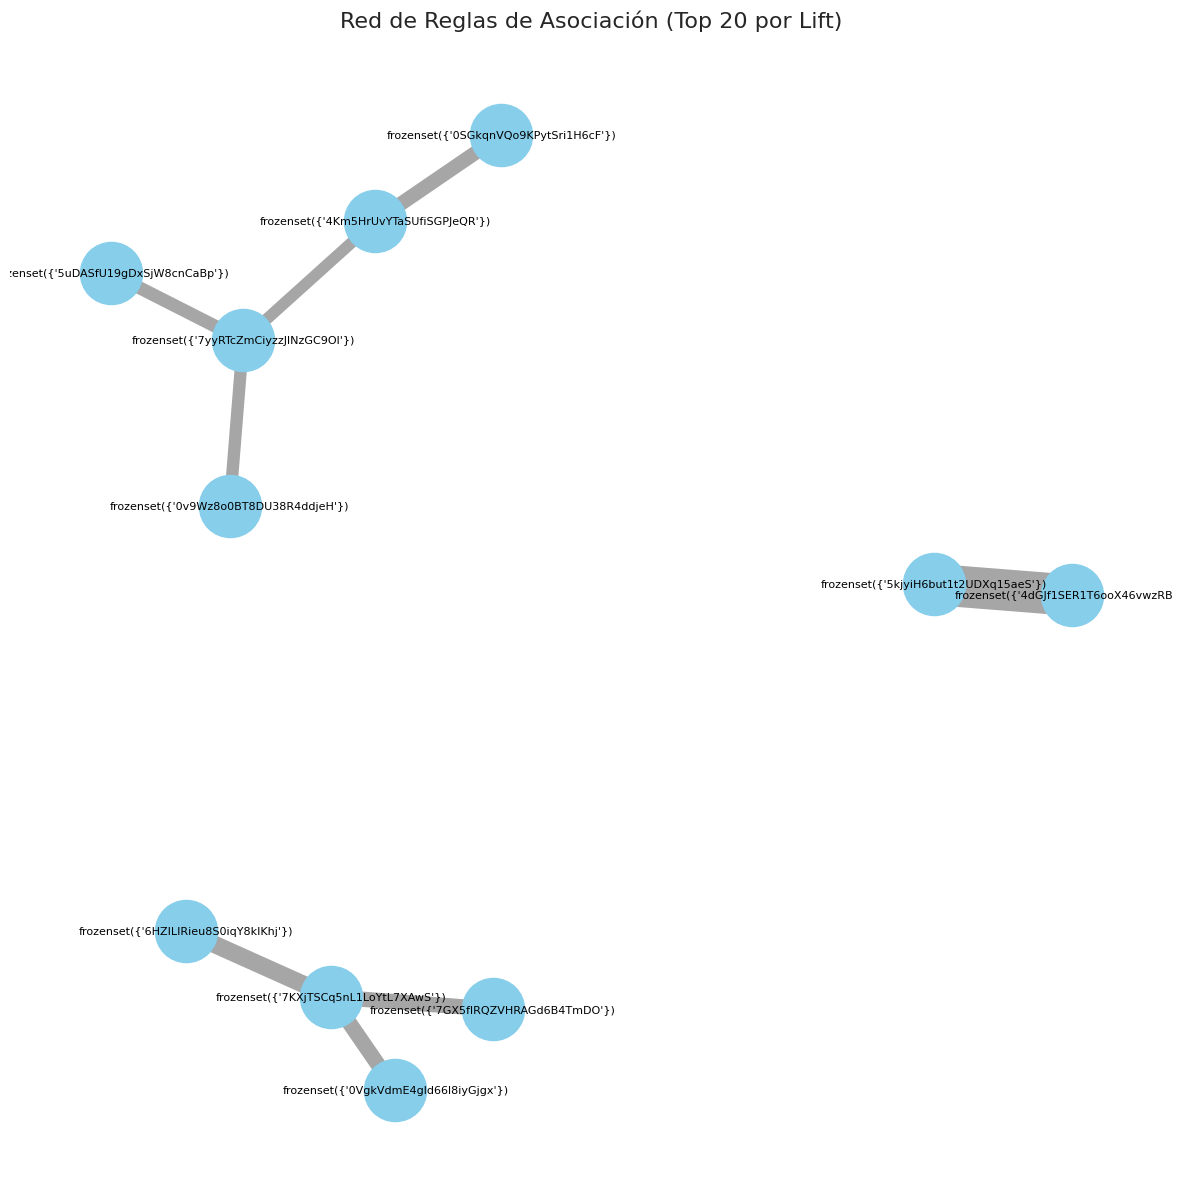

In [ ]:
# --- 4.3 Entregables ---

# 1. Guardar las reglas en un archivo CSV
rules_output_path = Path("data/results")
rules_output_path.mkdir(parents=True, exist_ok=True)
significant_rules.to_csv(rules_output_path / "reglas_asociacion_significativas.csv", index=False)
print(f"Reglas guardadas en '{rules_output_path / 'reglas_asociacion_significativas.csv'}'")


# 2. Visualización: Gráfico de Red de las 20 reglas principales
# (Puede ser lento si hay muchas reglas)
top_rules = significant_rules.head(20)

plt.figure(figsize=(15, 15))
G = nx.from_pandas_edgelist(top_rules,
                           source='antecedents',
                           target='consequents',
                           edge_attr=['lift', 'confidence'])

# Posiciones de los nodos
pos = nx.spring_layout(G, k=0.5, iterations=50)

# Dibujar nodos y etiquetas
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='skyblue')
nx.draw_networkx_labels(G, pos, font_size=8)

# Dibujar aristas con grosor basado en el lift
edge_width = [d['lift'] * 0.5 for (u, v, d) in G.edges(data=True)]
nx.draw_networkx_edges(G, pos, width=edge_width, edge_color='gray', alpha=0.7)

plt.title('Red de Reglas de Asociación (Top 20 por Lift)')
plt.axis('off')
plt.show()


Clustering con K-Means completado usando k=5.
Ejecutando DBSCAN...
DBSCAN completado.
Ejecutando MiniBatchKMeans...
MiniBatchKMeans completado.

Calculando métricas de evaluación...
Evaluando K-Means...
Evaluando DBSCAN...
DBSCAN no encontró suficientes clusters para ser evaluado.
Evaluando MiniBatchKMeans...

--- Tabla Comparativa de Modelos de Clustering de Tracks ---


,Algoritmo,Silhouette Score (más alto es mejor),Davies-Bouldin Score (más bajo es mejor)
0,K-Means,0.393663,0.850035
1,DBSCAN,-1.000000,-1.000000
2,MiniBatchKMeans,0.377706,0.861170



Generando visualización de clusters (ejemplo con K-Means)...


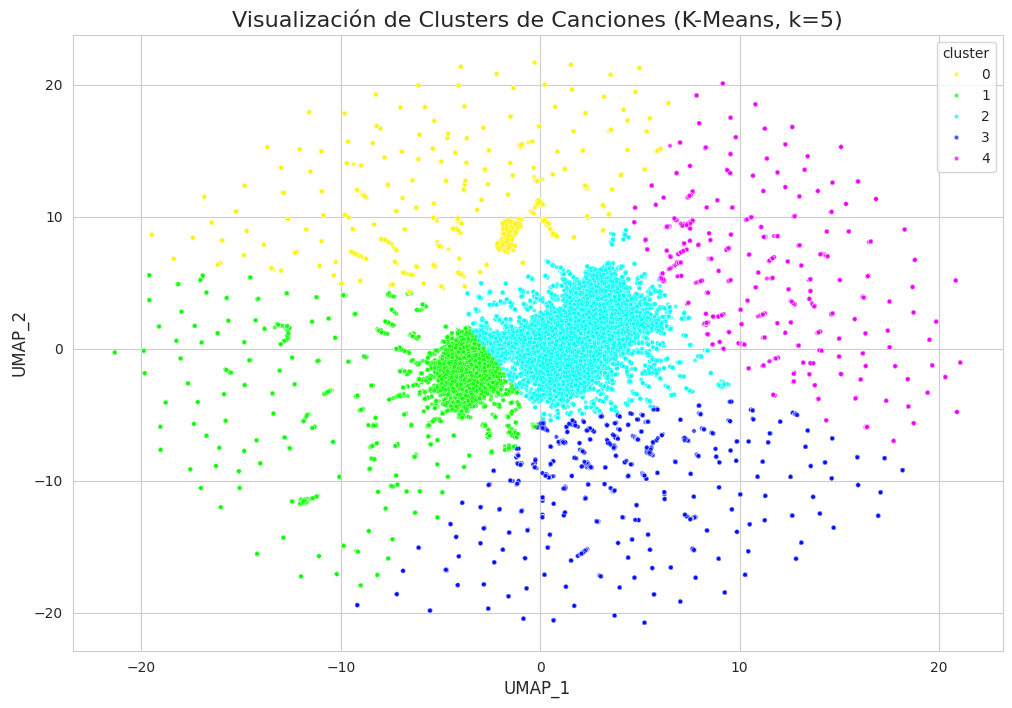

In [ ]:
UMAP_tracks = tracks_umap.copy()
UMAP_tracks_numeric = UMAP_tracks.select_dtypes(include=np.number)
# Basado en el gráfico, elegimos un valor para k (ej. k=8 donde la curva se aplana)
OPTIMAL_K = 5
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
# Usamos el DataFrame NUMÉRICO aquí también
track_labels_kmeans = kmeans.fit_predict(UMAP_tracks_numeric)

print(f"\nClustering con K-Means completado usando k={OPTIMAL_K}.")
# --- 5.A.2 Algoritmos 2 y 3: DBSCAN y MiniBatchKMeans (CORREGIDO Y OPTIMIZADO) ---

# --- DBSCAN ---
# DBSCAN puede ser lento en datasets grandes. Sus hiperparámetros son clave.
# Si esta parte también es muy lenta, considera ejecutarla sobre una muestra o ajustar 'eps'.
print("Ejecutando DBSCAN...")
dbscan = DBSCAN(eps=2.5, min_samples=20, n_jobs=-1) # n_jobs=-1 usa todos los núcleos de tu CPU
track_labels_dbscan = dbscan.fit_predict(UMAP_tracks_numeric)
print("DBSCAN completado.")


# --- MiniBatchKMeans (Reemplazo eficiente para Agglomerative Clustering) ---
# Este algoritmo es mucho más rápido y consume muchísima menos memoria.
print("Ejecutando MiniBatchKMeans...")
mini_batch_kmeans = MiniBatchKMeans(
    n_clusters=OPTIMAL_K, # Usamos el mismo k que en KMeans
    random_state=42,
    batch_size=256, # Tamaño del lote, un hiperparámetro a ajustar
    n_init=10
)
track_labels_minibatch = mini_batch_kmeans.fit_predict(UMAP_tracks_numeric)
print("MiniBatchKMeans completado.")

# --- 5.A.3 Evaluación Comparativa y Visualización (MODIFICADO Y CORREGIDO) ---

print("\nCalculando métricas de evaluación...")

# --- K-Means ---
# CORREGIDO: Usamos X_tracks_numeric para el cálculo de los scores.
print("Evaluando K-Means...")
score_s_kmeans = silhouette_score(UMAP_tracks_numeric, track_labels_kmeans)
score_db_kmeans = davies_bouldin_score(UMAP_tracks_numeric, track_labels_kmeans)

# --- DBSCAN ---
# CORREGIDO: Usamos X_tracks_numeric y mantenemos la optimización de muestreo para el cálculo.
print("Evaluando DBSCAN...")
mask_dbscan = track_labels_dbscan != -1 # Filtro para excluir puntos de ruido (label -1)

# Nos aseguramos de que DBSCAN haya encontrado más de 1 clúster para poder evaluar
if len(set(track_labels_dbscan[mask_dbscan])) > 1:
    # Usamos una muestra para que el cálculo del score sea rápido en datasets grandes
    # Tomamos una muestra de hasta 20,000 puntos que no sean ruido
    sample_size = min(20000, np.sum(mask_dbscan))

    # --- FIX START ---
    # Reset the index of X_tracks_numeric to allow for integer indexing
    UMAP_tracks_numeric_reset = UMAP_tracks_numeric.reset_index(drop=True)
    # Use the index of the filtered data (mask_dbscan) to sample from the reset DataFrame
    sample_indices = np.random.choice(UMAP_tracks_numeric_reset[mask_dbscan].index, size=sample_size, replace=False)

    score_s_dbscan = silhouette_score(UMAP_tracks_numeric_reset.loc[sample_indices], track_labels_dbscan[sample_indices])
    score_db_dbscan = davies_bouldin_score(UMAP_tracks_numeric_reset.loc[sample_indices], track_labels_dbscan[sample_indices])
    # --- FIX END ---
else:
    # If DBSCAN no encontró clusters (o solo uno), asignamos un score inválido
    print("DBSCAN no encontró suficientes clusters para ser evaluado.")
    score_s_dbscan = -1
    score_db_dbscan = -1

# --- MiniBatchKMeans ---
# NUEVO: Reemplazamos la evaluación de Agglomerative por la de MiniBatchKMeans.
print("Evaluando MiniBatchKMeans...")
score_s_minibatch = silhouette_score(UMAP_tracks_numeric, track_labels_minibatch)
score_db_minibatch = davies_bouldin_score(UMAP_tracks_numeric, track_labels_minibatch)


# --- Crear tabla de resultados ---
# CORREGIDO: Actualizamos la lista de algoritmos y las variables de los scores.
results = pd.DataFrame({
    'Algoritmo': ['K-Means', 'DBSCAN', 'MiniBatchKMeans'],
    'Silhouette Score (más alto es mejor)': [score_s_kmeans, score_s_dbscan, score_s_minibatch],
    'Davies-Bouldin Score (más bajo es mejor)': [score_db_kmeans, score_db_dbscan, score_db_minibatch]
})

print("\n--- Tabla Comparativa de Modelos de Clustering de Tracks ---")
display(results)


# --- Visualización de Clusters ---
# Este bloque no necesita cambios, pero lo mantenemos por completitud.
# Muestra los resultados de K-Means como ejemplo.
# Nota: Para visualizar otros resultados, simplemente cambia 'track_labels_kmeans'
# por 'track_labels_minibatch' o 'track_labels_dbscan'.

print("\nGenerando visualización de clusters (ejemplo con K-Means)...")
viz_df = tracks_umap.copy()
viz_df['cluster'] = track_labels_kmeans

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=viz_df,
    x='UMAP_1',
    y='UMAP_2',
    hue='cluster',
    palette=sns.color_palette("hsv", n_colors=OPTIMAL_K),
    s=10, # Tamaño de los puntos
    alpha=0.7,
    legend='full'
)
plt.title(f'Visualización de Clusters de Canciones (K-Means, k={OPTIMAL_K})')
plt.show()
